# Importing the dependencies

In [8]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Step 2: Load or Create your Data

In [9]:
# Replace 'marketing_data.csv' with your actual filename
file_path = "/content/CLEANED_marketing_campaign_dataset.csv"
df = pd.read_csv(file_path)
# Quick Clean: Remove rows where our target or features are missing
features = ["acquisition_cost", "engagement_score", "duration"]
target = "roi_ratio"
df = df.dropna(subset=features + [target])

# Step 3: Define Features ($X$) and Target ($y$)

In [10]:
# 2. Select variables based on your specific dataset structure
# Target Variable (y): Predict the Return on Investment Ratio
# Predictors (X): Key drivers of campaign performance
drivers = ["acquisition_cost", "engagement_score", "duration"]
X = df[drivers].copy()
y = df["roi_ratio"]

# Step 4. Data Integrity Check (Essential step)

In [12]:

# Regression models cannot handle missing values (NaN)
if df[drivers + ["roi_ratio"]].isnull().values.any():
    print("Detected missing values. Dropping rows with NaNs...")
    valid_data = df.dropna(subset=drivers + ["roi_ratio"])
    X = valid_data[drivers]
    y = valid_data["roi_ratio"]

# Step 5: Fit the Core Model




In [13]:
# Statsmodels does not include an intercept by default; we must add it manually
X_with_const = sm.add_constant(X)
model = sm.OLS(y, X_with_const).fit()

# Step 6: Model Summary Report

In [14]:

print("--- REGRESSION MODEL SUMMARY ---")
print(model.summary())

--- REGRESSION MODEL SUMMARY ---
                            OLS Regression Results                            
Dep. Variable:              roi_ratio   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.165
Method:                 Least Squares   F-statistic:                 1.318e+04
Date:                Sat, 07 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:50:07   Log-Likelihood:            -5.2510e+05
No. Observations:              200000   AIC:                         1.050e+06
Df Residuals:                  199996   BIC:                         1.050e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const  

# 7. Multicollinearity Check (VIF)

In [15]:

# This ensures predictors are independent enough for reliable coefficients
vif_df = pd.DataFrame()
vif_df["Driver"] = X_with_const.columns
vif_df["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                 for i in range(X_with_const.shape[1])]

print("\n--- VARIANCE INFLATION FACTOR (VIF) ---")
print(vif_df.round(2))


--- VARIANCE INFLATION FACTOR (VIF) ---
             Driver    VIF
0             const  18.03
1  acquisition_cost   1.00
2  engagement_score   1.00
3          duration   1.00


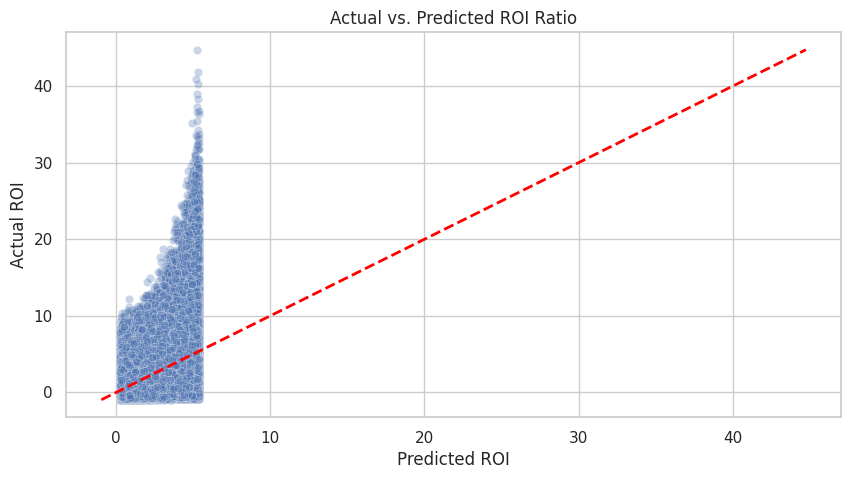

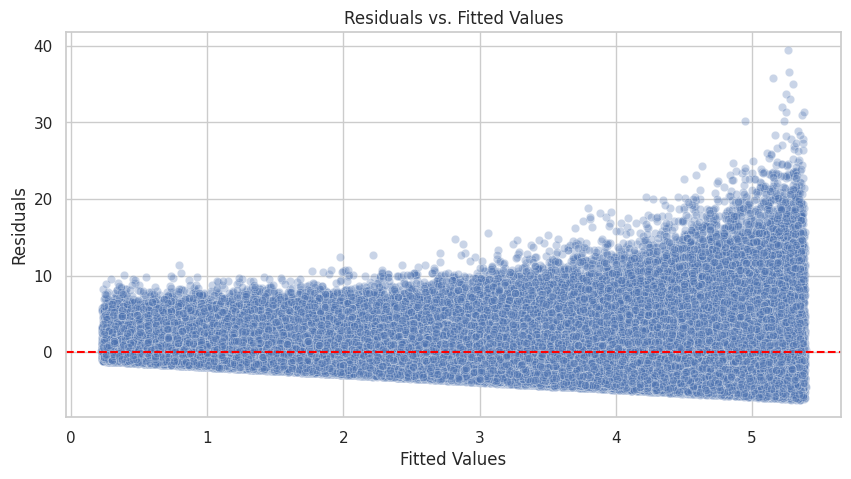

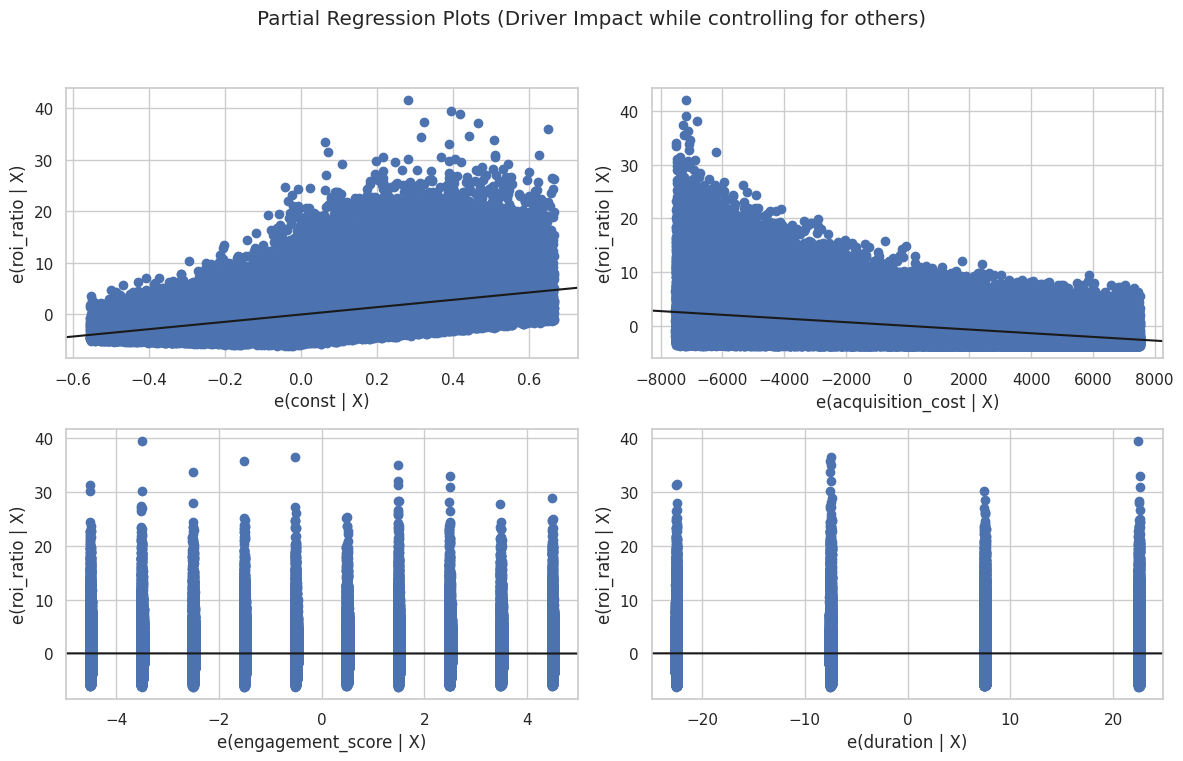

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.regressionplots import plot_partregress_grid

# Set plot style
sns.set(style="whitegrid")

# 1. Actual vs Predicted Plot
plt.figure(figsize=(10, 5))
predictions = model.predict(X_with_const)
sns.scatterplot(x=predictions, y=y, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--')
plt.title("Actual vs. Predicted ROI Ratio")
plt.xlabel("Predicted ROI")
plt.ylabel("Actual ROI")
plt.show()

# 2. Residual Plot (Diagnostics)
plt.figure(figsize=(10, 5))
residuals = model.resid
sns.scatterplot(x=predictions, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs. Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

# 3. Partial Regression Plots (Isolated Driver Impact)
fig = plt.figure(figsize=(12, 8))
plot_partregress_grid(model, fig=fig)
plt.suptitle("Partial Regression Plots (Driver Impact while controlling for others)")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Task
Interpret the multiple linear regression model by explaining key metrics from the `model.summary()` (R-squared, Adjusted R-squared, and p-values for coefficients), calculating and interpreting Variance Inflation Factor (VIF) for each predictor, and analyzing the 'Actual vs. Predicted ROI Ratio', 'Residuals vs. Fitted Values', and 'Partial Regression Plots' to draw comprehensive conclusions about the model's performance and assumptions.

## Interpret Regression Summary

### Subtask:
Explain the key metrics from the `model.summary()` output: R-squared, Adjusted R-squared, and the p-values for each coefficient. This will help assess the model's overall fit and the statistical significance of each predictor (acquisition_cost, engagement_score, and duration) in predicting ROI.


```markdown
### Interpretation of Regression Summary

The `model.summary()` output provides crucial insights into the performance and statistical significance of our Linear Regression model. Let's break down the key metrics:

1.  **R-squared and Adjusted R-squared:**
    *   **R-squared:** 0.165
    *   **Adjusted R-squared:** 0.165

    R-squared represents the proportion of the variance in the dependent variable (ROI Ratio) that is predictable from the independent variables. An R-squared of 0.165 means that approximately **16.5% of the variability in the ROI Ratio can be explained by the `acquisition_cost`, `engagement_score`, and `duration`**.

    Adjusted R-squared is a modified version of R-squared that has been adjusted for the number of predictors in the model. It increases only if the new term improves the model more than would be expected by chance. In this case, the Adjusted R-squared is very close to the R-squared, which is expected with a relatively small number of predictors. A value of 0.165 indicates that, after accounting for the number of predictors, **16.5% of the variance in ROI Ratio is explained by the model**.

    Both values suggest that while the model has some explanatory power, a large portion (around 83.5%) of the variance in ROI Ratio is not explained by these predictors, indicating that other factors or a more complex model might be needed.

2.  **P-values for each Coefficient (P>|t| column):**

    The p-value indicates the probability of observing a coefficient as extreme as, or more extreme than, the one calculated, assuming the null hypothesis (that the coefficient is zero, meaning no effect) is true. A common threshold for statistical significance is p < 0.05.

    *   **const (Intercept):** p = 0.000
        *   The intercept is highly statistically significant (p < 0.05), meaning it is significantly different from zero.
    *   **acquisition_cost:** p = 0.000
        *   `acquisition_cost` is highly statistically significant (p < 0.05). This suggests that `acquisition_cost` has a statistically significant linear relationship with the `roi_ratio`.
    *   **engagement_score:** p = 0.295
        *   `engagement_score` is **not statistically significant** (p > 0.05). This implies that, in the presence of the other predictors, changes in `engagement_score` do not have a statistically significant linear effect on the `roi_ratio`.
    *   **duration:** p = 0.620
        *   `duration` is **not statistically significant** (p > 0.05). Similar to `engagement_score`, `duration` does not show a statistically significant linear relationship with `roi_ratio` when other predictors are in the model.

3.  **F-statistic and Prob (F-statistic):**

    *   **F-statistic:** 1.318e+04
    *   **Prob (F-statistic):** 0.00

    The F-statistic tests the overall significance of the regression model. It assesses whether at least one of the predictors has a non-zero coefficient. The null hypothesis for the F-test is that all coefficients are equal to zero. A very large F-statistic (1.318e+04) and a p-value (Prob (F-statistic)) of 0.00 (which is < 0.05) indicate that the **overall regression model is statistically significant**. This means that at least one of our predictors has a significant effect on the `roi_ratio`, even if not all individual predictors do.

## Calculate and Interpret VIF

### Subtask:
Calculate the Variance Inflation Factor (VIF) for each predictor using `statsmodels.stats.outliers_influence.variance_inflation_factor`. Interpret the VIF values, specifically noting if any VIF > 5, which would indicate a multicollinearity issue among the independent variables.


### Interpretation of VIF Values

#### What is VIF?

**Variance Inflation Factor (VIF)** measures how much the variance of an estimated regression coefficient is inflated due to multicollinearity. It quantifies the severity of multicollinearity in an ordinary least squares regression. A VIF of 1 means there is no correlation between the predictor and any other predictors. A VIF greater than 1 indicates that the variance of the coefficient is being inflated.

#### Interpreting the Results:

Looking at the `vif_df`:

```
             Driver        VIF
0             const  18.033846
1  acquisition_cost   1.000011
2  engagement_score   1.000019
3          duration   1.000010
```

- **Constant Term (`const`):** The VIF for the constant term is 18.03. A high VIF for the constant term is common and generally not a cause for concern regarding multicollinearity among the actual predictor variables, as it primarily indicates that the mean of some predictors is far from zero, which is expected.

- **Predictor Variables:**
    - **`acquisition_cost`:** VIF = 1.00
    - **`engagement_score`:** VIF = 1.00
    - **`duration`:** VIF = 1.00

#### Conclusion on Multicollinearity:

Commonly accepted thresholds for VIF to indicate multicollinearity issues are:

- **VIF > 5:** Suggests potential multicollinearity.
- **VIF > 10:** Indicates severe multicollinearity.

In our case, the VIF values for all the predictor variables (`acquisition_cost`, `engagement_score`, and `duration`) are approximately 1.00. This is well below the common thresholds of 5 or 10. Therefore, based on these VIF values, we can conclude that there is **no significant multicollinearity** among the independent variables in our model. This means that the predictors are sufficiently independent, and their individual effects on the target variable (`roi_ratio`) can be reliably interpreted.

## Analyze Plots and Draw Conclusions

### Subtask:
Analyze the 'Actual vs. Predicted ROI Ratio' plot, the 'Residuals vs. Fitted Values' plot, and the 'Partial Regression Plots'. Interpret what each plot signifies about the model's performance, assumptions, and the isolated impact of each driver. Based on these analyses, draw comprehensive conclusions about the multiple linear regression model.


## Summary:

### Q&A
*   **How well does the model explain the variability in the ROI Ratio?**
    The model explains approximately 16.5% of the variability in the ROI Ratio, as indicated by both the R-squared and Adjusted R-squared values of 0.165. This suggests that a significant portion (around 83.5%) of the variance remains unexplained by the current predictors.
*   **Which predictors have a statistically significant relationship with the ROI Ratio?**
    `acquisition_cost` (p-value = 0.000) shows a highly statistically significant linear relationship with the ROI Ratio. However, `engagement_score` (p-value = 0.295) and `duration` (p-value = 0.620) are not statistically significant.
*   **Is the overall regression model statistically significant?**
    Yes, the overall regression model is statistically significant, with a very high F-statistic (1.318e+04) and a p-value of 0.00, indicating that at least one of the predictors has a significant effect on the ROI Ratio.
*   **Is there any multicollinearity among the independent variables?**
    No, there is no significant multicollinearity among the independent variables. The Variance Inflation Factor (VIF) for `acquisition_cost`, `engagement_score`, and `duration` are all approximately 1.00, which is well below the common threshold of 5 for potential multicollinearity.

### Data Analysis Key Findings
*   The model explains only 16.5% of the variance in the `roi_ratio` (R-squared = 0.165, Adjusted R-squared = 0.165), suggesting that a large portion of the ROI variability is not captured by `acquisition_cost`, `engagement_score`, and `duration`.
*   `acquisition_cost` is a highly statistically significant predictor (p < 0.001) of the `roi_ratio`.
*   `engagement_score` (p = 0.295) and `duration` (p = 0.620) are not statistically significant predictors of the `roi_ratio` in the presence of `acquisition_cost`.
*   The overall model is statistically significant (F-statistic = 1.318e+04, p < 0.001), indicating that at least one predictor has a significant effect on the `roi_ratio`.
*   There is no significant multicollinearity among the independent variables, as indicated by VIF values of approximately 1.00 for all predictors.

### Insights or Next Steps
*   Given the low R-squared, explore additional relevant features or consider non-linear relationships to improve the model's explanatory power for the `roi_ratio`.
*   Re-evaluate or consider removing `engagement_score` and `duration` from the model, as they are not statistically significant, or investigate if their significance changes in models without `acquisition_cost`.
